# Open Play vs Set Piece Goals

Analyze how goals are scored across the league: open play vs set pieces (corners, free kicks, throw-ins) vs penalties. Per-team breakdown of attacking style profiles.

In [20]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# ─── Path Configuration ──────────────────────────────────────────
LEAGUE = 'cg'  # 'cg' = Montenegro 1. CFL | 'srb' = Serbian SuperLiga

RAW_MATCH_DIR  = Path('..') / 'data' / 'raw' / LEAGUE / 'raw_by_match'
DATA_DIR       = Path('..') / 'data' / 'processed' / LEAGUE
FIGURES_DIR    = Path('..') / 'outputs' / LEAGUE / 'figures'
FINAL_DIR      = Path('..') / 'outputs' / LEAGUE / 'final_posts'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ─── Visual Constants ────────────────────────────────────────
BG_COLOR   = '#0a0a0a'
GOLD       = '#d4af37'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#A0A0A0'
GREEN      = '#2ecc71'
RED        = '#e74c3c'
BLUE       = '#3498db'
ORANGE     = '#f39c12'
PURPLE     = '#9b59b6'
TEAL       = '#1abc9c'

In [21]:
# ─── Load All Shots ──────────────────────────────────────────
all_shots = []
for match_dir in sorted(RAW_MATCH_DIR.iterdir()):
    if not match_dir.is_dir():
        continue
    shots_file = match_dir / 'match_shots.csv'
    if shots_file.exists():
        try:
            df = pd.read_csv(shots_file)
            if len(df) > 0:
                df['match_id'] = int(match_dir.name)
                all_shots.append(df)
        except Exception:
            continue

shots = pd.concat(all_shots, ignore_index=True)
shots['isGoal'] = (shots['shotType'] == 'goal').astype(int)
shots['xg'] = pd.to_numeric(shots['xg'], errors='coerce').fillna(0)

# ─── Load match metadata for team mapping ────────────────────
matches = pd.read_csv(DATA_DIR / 'matches_metadata.csv')
teams_meta = pd.read_csv(DATA_DIR / 'teams_metadata.csv')
short_names = teams_meta.set_index('team_id')['short_name'].to_dict()

# Map each shot to its team
home_map = matches.set_index('match_id')['homeTeam_id'].to_dict()
away_map = matches.set_index('match_id')['awayTeam_id'].to_dict()
home_name_map = matches.set_index('match_id')['homeTeam_name'].to_dict()
away_name_map = matches.set_index('match_id')['awayTeam_name'].to_dict()

shots['_is_home'] = shots['isHome'].astype(str).str.lower() == 'true'
shots['team_id'] = shots.apply(
    lambda r: home_map.get(r['match_id']) if r['_is_home'] else away_map.get(r['match_id']), axis=1
)
shots['team_name'] = shots.apply(
    lambda r: home_name_map.get(r['match_id']) if r['_is_home'] else away_name_map.get(r['match_id']), axis=1
)

# Filter own goals
shots = shots[shots['situation'] != 'own-goal'].copy()

print(f'✅ Loaded {len(shots)} shots')
print(f'   Goals: {shots["isGoal"].sum()}')
print(f'\nSituation breakdown (all shots):')
print(shots['situation'].value_counts().to_string())
print(f'\nSituation breakdown (goals only):')
print(shots[shots['isGoal'] == 1]['situation'].value_counts().to_string())

✅ Loaded 2494 shots
   Goals: 291

Situation breakdown (all shots):
situation
regular               1618
corner                 317
throw-in-set-piece     275
set-piece              155
free-kick               95
penalty                 34

Situation breakdown (goals only):
situation
regular               171
corner                 33
penalty                30
throw-in-set-piece     27
set-piece              20
free-kick              10


In [22]:
# ─── Classify Situations ─────────────────────────────────────
# Group into broader categories
situation_map = {
    'regular': 'Otvorena igra',
    'penalty': 'Penal',
    'free-kick': 'Prekid',
    'corner': 'Prekid',
    'set-piece': 'Prekid',
    'throw-in-set-piece': 'Prekid',
}

shots['situation_group'] = shots['situation'].map(situation_map).fillna('Ostalo')
goals = shots[shots['isGoal'] == 1].copy()

# Also keep detailed set-piece breakdown
detail_map = {
    'regular': 'Otvorena igra',
    'penalty': 'Penal',
    'free-kick': 'Slobodan udarac',
    'corner': 'Korner',
    'set-piece': 'Set piece',
    'throw-in-set-piece': 'Aut',
}
goals['situation_detail'] = goals['situation'].map(detail_map).fillna('Ostalo')

print('Goal breakdown by group:')
group_counts = goals['situation_group'].value_counts()
for g, n in group_counts.items():
    pct = n / len(goals) * 100
    print(f'  {g}: {n} ({pct:.1f}%)')

print(f'\nDetailed breakdown:')
detail_counts = goals['situation_detail'].value_counts()
for d, n in detail_counts.items():
    pct = n / len(goals) * 100
    print(f'  {d}: {n} ({pct:.1f}%)')

Goal breakdown by group:
  Otvorena igra: 171 (58.8%)
  Prekid: 90 (30.9%)
  Penal: 30 (10.3%)

Detailed breakdown:
  Otvorena igra: 171 (58.8%)
  Korner: 33 (11.3%)
  Penal: 30 (10.3%)
  Aut: 27 (9.3%)
  Set piece: 20 (6.9%)
  Slobodan udarac: 10 (3.4%)


✅ Saved: goal_type_donut.png


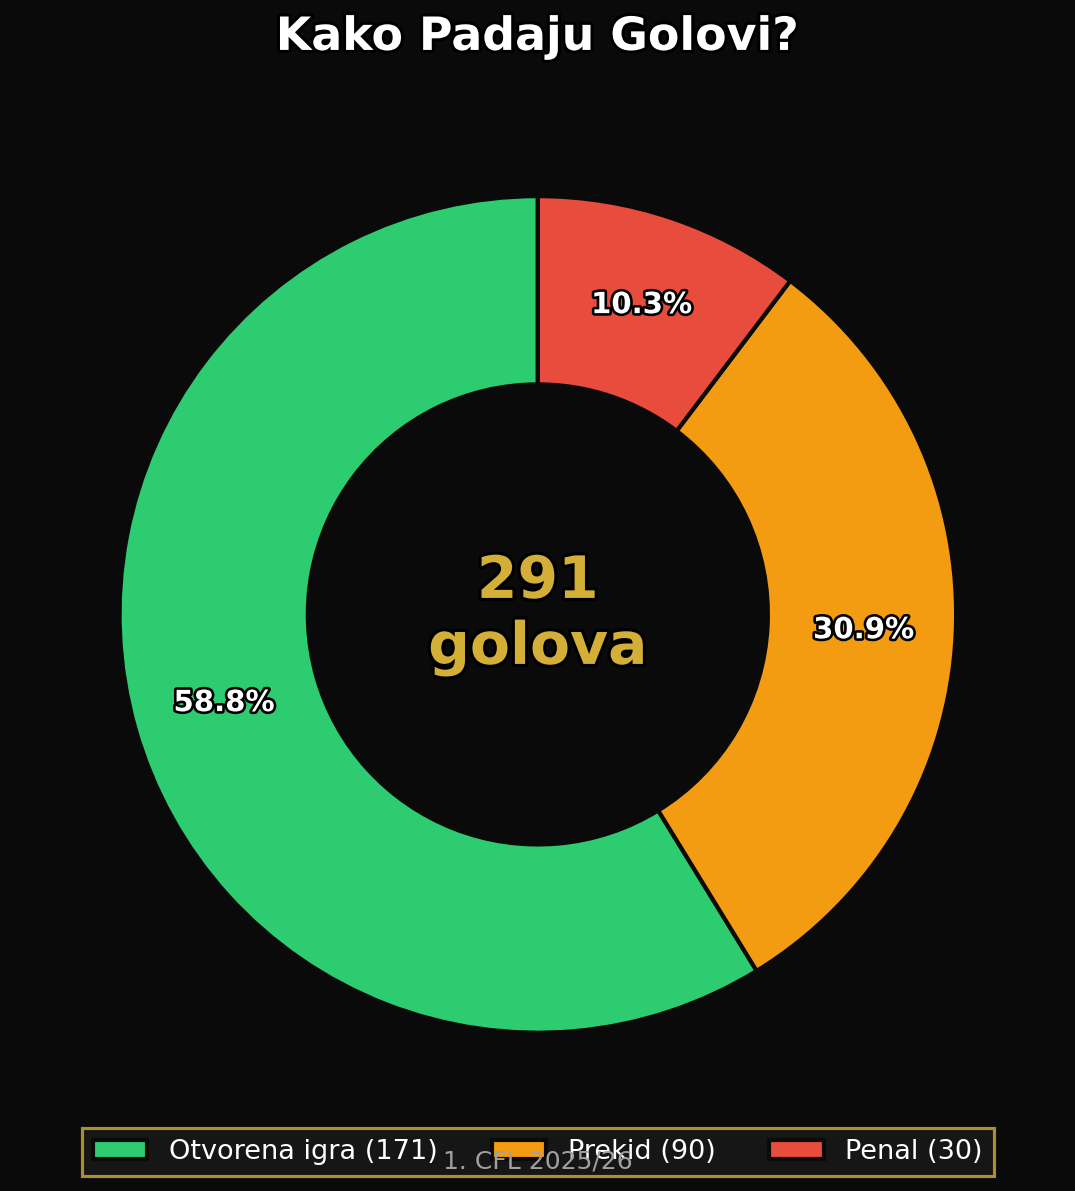

In [23]:
# ─── Figure 1: League-wide Goal Breakdown (Pie/Donut) ────────
GROUP_COLORS = {
    'Otvorena igra': GREEN,
    'Prekid': ORANGE,
    'Penal': RED,
}

group_data = goals['situation_group'].value_counts()
labels = group_data.index.tolist()
sizes = group_data.values
colors = [GROUP_COLORS.get(l, TEXT_GREY) for l in labels]
total = sizes.sum()

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

wedges, texts, autotexts = ax.pie(
    sizes, labels=None, colors=colors, startangle=90,
    autopct=lambda p: f'{p:.1f}%', pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor=BG_COLOR, linewidth=2),
)

for t in autotexts:
    t.set_fontsize(14)
    t.set_fontweight('bold')
    t.set_color(TEXT_WHITE)
    t.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])

# Centre text
ct = ax.text(0, 0, f'{total}\ngolova', fontsize=28, fontweight='bold', color=GOLD,
             ha='center', va='center')
ct.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()])

# Legend
legend_labels = [f'{l} ({s})' for l, s in zip(labels, sizes)]
legend = ax.legend(wedges, legend_labels, loc='lower center', fontsize=13,
                   frameon=True, fancybox=False, edgecolor=GOLD, facecolor='#1a1a1a',
                   labelcolor=TEXT_WHITE, ncol=3, bbox_to_anchor=(0.5, -0.05))
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('Kako Padaju Golovi?',
                     fontsize=22, fontweight='bold', color=TEXT_WHITE, pad=20)
title.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()])

fig.text(0.5, 0.02, '1. CFL 2025/26', fontsize=12, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goal_type_donut.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: goal_type_donut.png')
plt.show()

✅ Saved: goal_type_detailed_bar.png


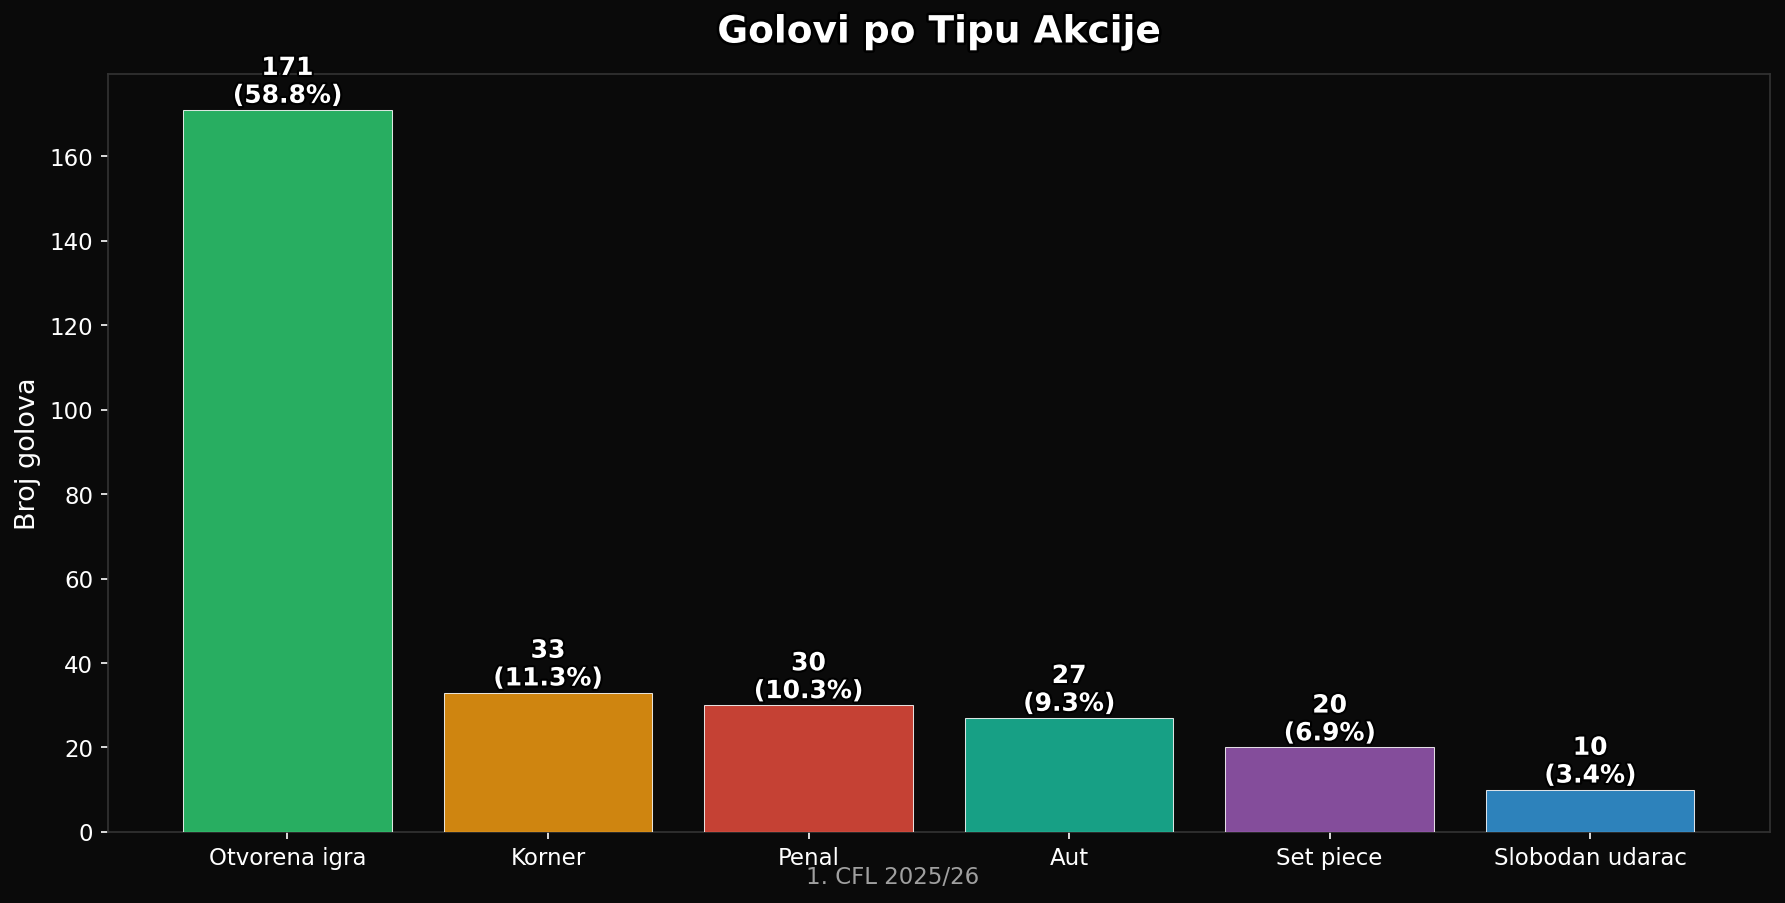

In [24]:
# ─── Figure 2: Detailed Set Piece Breakdown ─────────────────
DETAIL_COLORS = {
    'Otvorena igra': GREEN,
    'Korner': ORANGE,
    'Slobodan udarac': BLUE,
    'Set piece': PURPLE,
    'Aut': TEAL,
    'Penal': RED,
}

detail_data = goals['situation_detail'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.bar(range(len(detail_data)), detail_data.values,
              color=[DETAIL_COLORS.get(l, TEXT_GREY) for l in detail_data.index],
              edgecolor='white', linewidth=0.5, alpha=0.85, zorder=3)

for i, (label, val) in enumerate(zip(detail_data.index, detail_data.values)):
    pct = val / len(goals) * 100
    t = ax.text(i, val + 0.5, f'{val}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color=TEXT_WHITE)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_xticks(range(len(detail_data)))
ax.set_xticklabels(detail_data.index, fontsize=12, color=TEXT_WHITE)
ax.set_ylabel('Broj golova', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

title = ax.set_title('Golovi po Tipu Akcije',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, '1. CFL 2025/26', fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goal_type_detailed_bar.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: goal_type_detailed_bar.png')
plt.show()

✅ Saved: goals_open_vs_setpiece_by_team.png


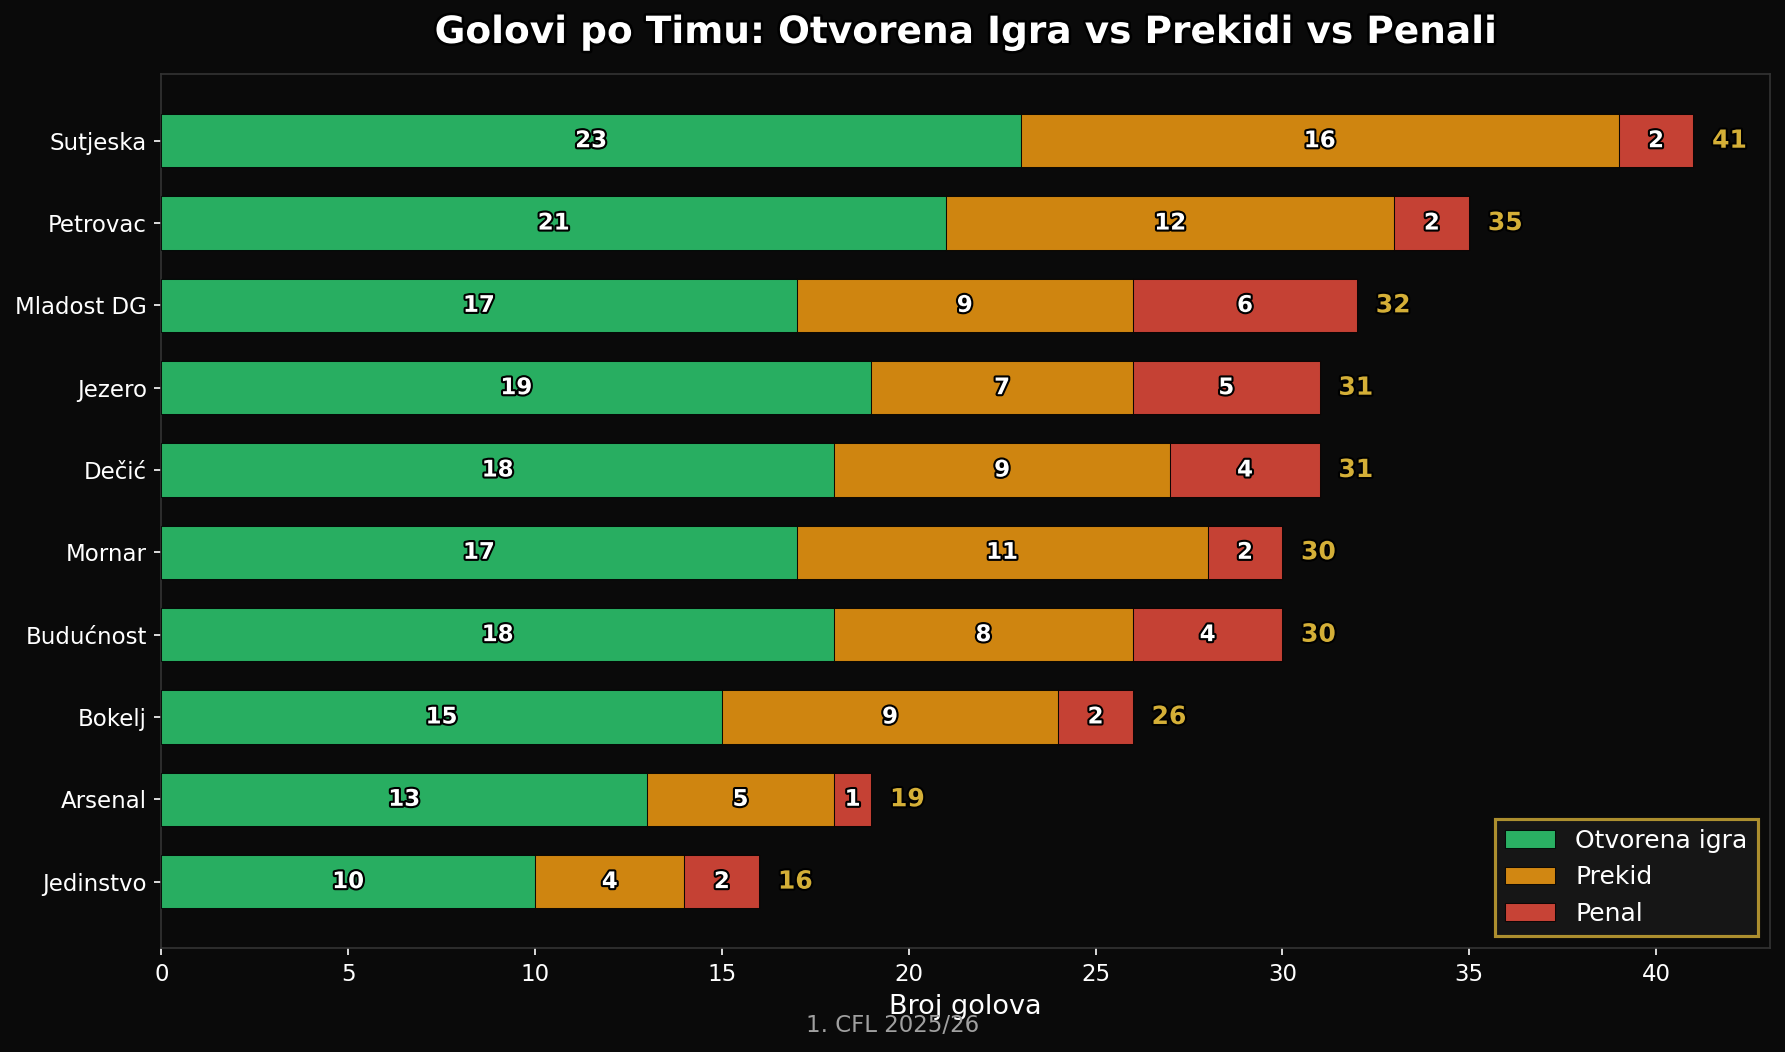

In [25]:
# ─── Figure 3: Per-Team Stacked Bar — Open Play vs Set Piece vs Penalty ──
team_goals = goals.groupby(['team_name', 'situation_group']).size().unstack(fill_value=0)

# Ensure all columns exist
for col in ['Otvorena igra', 'Prekid', 'Penal']:
    if col not in team_goals.columns:
        team_goals[col] = 0

team_goals['total'] = team_goals.sum(axis=1)
team_goals = team_goals.sort_values('total', ascending=True)

# Short names
team_id_map = teams_meta.set_index('team_name')['short_name'].to_dict()
team_goals['short'] = team_goals.index.map(lambda x: team_id_map.get(x, x.replace('FK ', '').replace('OFK ', '')))

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

y = np.arange(len(team_goals))
bar_height = 0.65

# Stacked horizontal bars
left = np.zeros(len(team_goals))
for col, color in [('Otvorena igra', GREEN), ('Prekid', ORANGE), ('Penal', RED)]:
    vals = team_goals[col].values
    ax.barh(y, vals, bar_height, left=left, color=color, edgecolor='black',
            linewidth=0.5, alpha=0.85, label=col, zorder=3)
    # Value labels inside bars
    for i, v in enumerate(vals):
        if v > 0:
            cx = left[i] + v / 2
            t = ax.text(cx, y[i], str(v), ha='center', va='center',
                        fontsize=11, fontweight='bold', color=TEXT_WHITE)
            t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                                path_effects.Normal()])
    left += vals

# Total labels
for i, tot in enumerate(team_goals['total'].values):
    t = ax.text(tot + 0.5, y[i], str(tot), ha='left', va='center',
                fontsize=12, fontweight='bold', color=GOLD)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_yticks(y)
ax.set_yticklabels(team_goals['short'].values, fontsize=12, color=TEXT_WHITE)
ax.set_xlabel('Broj golova', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

legend = ax.legend(fontsize=12, fancybox=False, edgecolor=GOLD, facecolor='#1a1a1a',
                   labelcolor=TEXT_WHITE, loc='lower right')
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('Golovi po Timu: Otvorena Igra vs Prekidi vs Penali',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, '1. CFL 2025/26', fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goals_open_vs_setpiece_by_team.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: goals_open_vs_setpiece_by_team.png')
plt.show()

✅ Saved: goals_pct_open_vs_setpiece_by_team.png


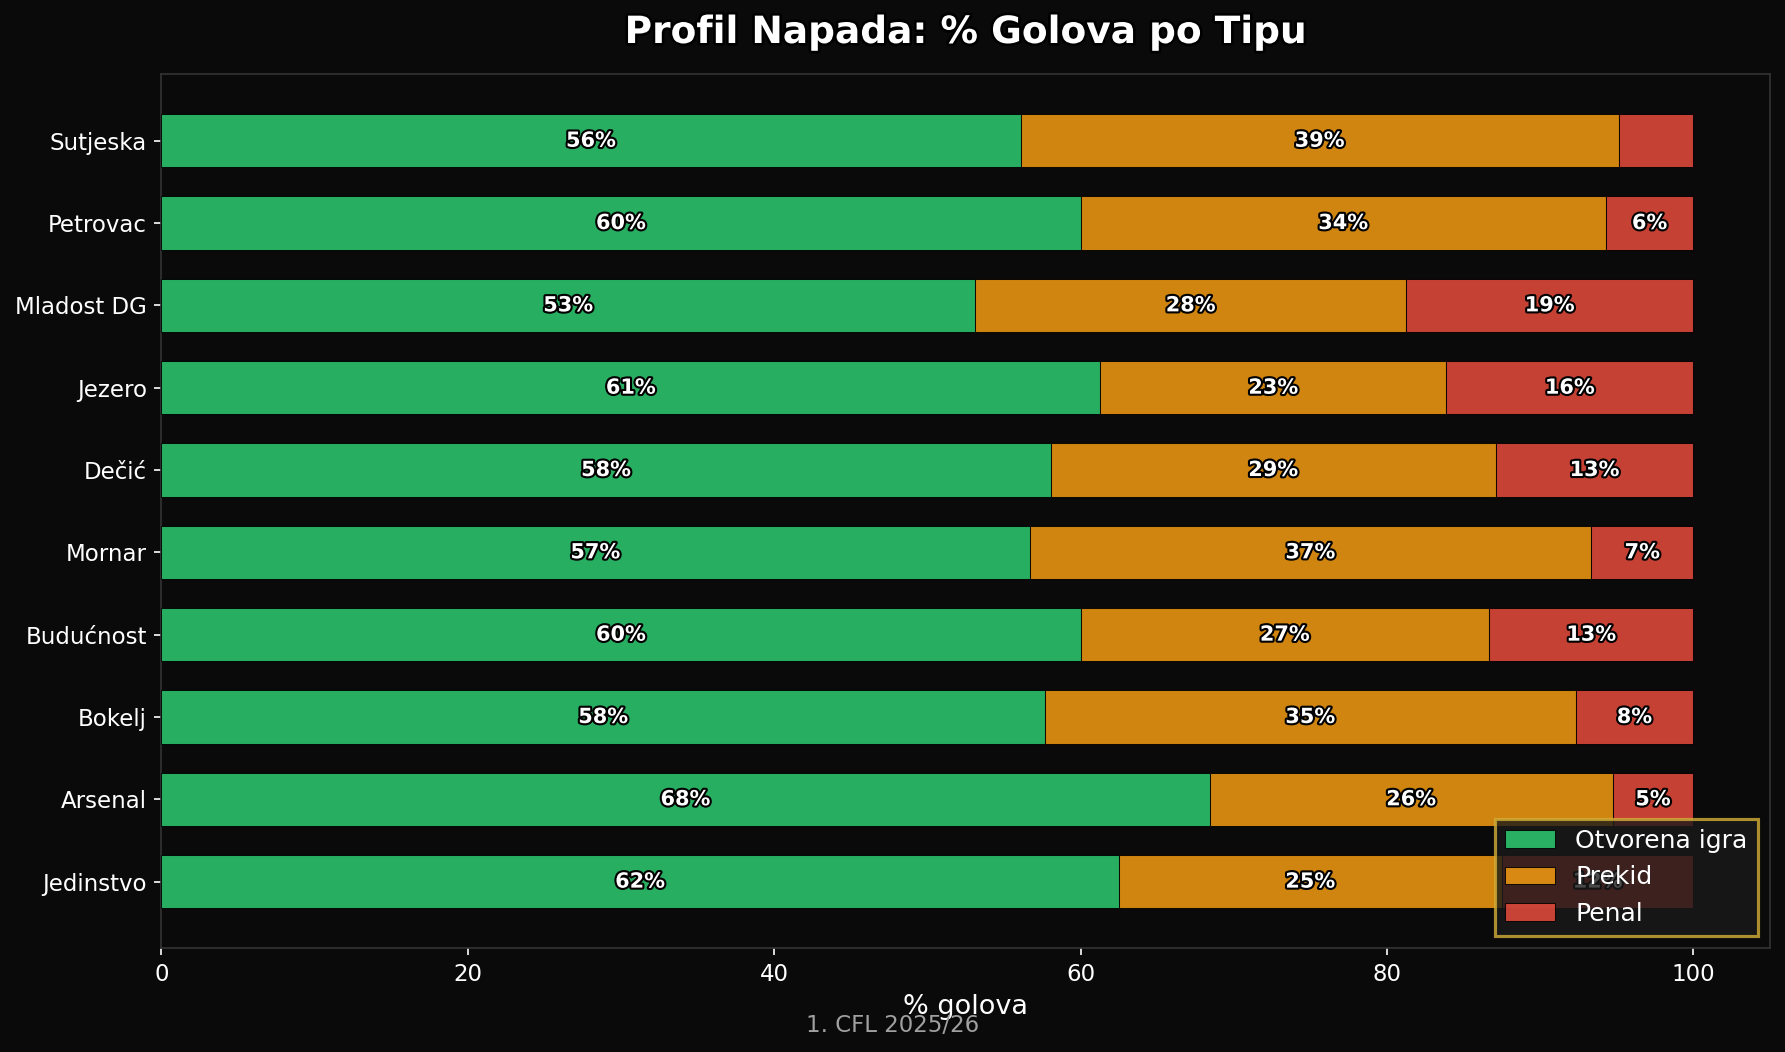

In [26]:
# ─── Figure 4: Per-Team % Breakdown (Normalized Stacked Bar) ─
team_pct = team_goals[['Otvorena igra', 'Prekid', 'Penal']].div(team_goals['total'], axis=0) * 100
team_pct['short'] = team_goals['short']

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

y = np.arange(len(team_pct))
bar_height = 0.65
left = np.zeros(len(team_pct))

for col, color in [('Otvorena igra', GREEN), ('Prekid', ORANGE), ('Penal', RED)]:
    vals = team_pct[col].values
    ax.barh(y, vals, bar_height, left=left, color=color, edgecolor='black',
            linewidth=0.5, alpha=0.85, label=col, zorder=3)
    for i, v in enumerate(vals):
        if v > 5:  # Only label if wide enough
            cx = left[i] + v / 2
            t = ax.text(cx, y[i], f'{v:.0f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=TEXT_WHITE)
            t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                                path_effects.Normal()])
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(team_pct['short'].values, fontsize=12, color=TEXT_WHITE)
ax.set_xlabel('% golova', fontsize=13, color=TEXT_WHITE)
ax.set_xlim(0, 105)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

legend = ax.legend(fontsize=12, fancybox=False, edgecolor=GOLD, facecolor='#1a1a1a',
                   labelcolor=TEXT_WHITE, loc='lower right')
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('Profil Napada: % Golova po Tipu',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, '1. CFL 2025/26', fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goals_pct_open_vs_setpiece_by_team.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: goals_pct_open_vs_setpiece_by_team.png')
plt.show()

In [27]:
# ─── Figure 5: xG Efficiency — Open Play vs Set Piece ───────
# Compare actual goals vs xG by situation group per team
eff = goals.groupby(['team_name', 'situation_group']).agg(
    goals_scored=('isGoal', 'sum'),
    total_xg=('xg', 'sum'),
).reset_index()
eff['overperformance'] = eff['goals_scored'] - eff['total_xg']

# Also get shot-level xG (not just goals)
shot_eff = shots.groupby(['team_name', 'situation_group']).agg(
    total_shots=('isGoal', 'count'),
    goals_scored=('isGoal', 'sum'),
    total_xg=('xg', 'sum'),
).reset_index()
shot_eff['conversion'] = (shot_eff['goals_scored'] / shot_eff['total_shots'] * 100).round(1)
shot_eff['xg_per_shot'] = (shot_eff['total_xg'] / shot_eff['total_shots']).round(3)

# Display summary
for sg in ['Otvorena igra', 'Prekid', 'Penal']:
    sub = shot_eff[shot_eff['situation_group'] == sg]
    print(f'\n── {sg} ──')
    print(f'  Total shots: {sub["total_shots"].sum()}')
    print(f'  Total goals: {sub["goals_scored"].sum()}')
    print(f'  Total xG:    {sub["total_xg"].sum():.1f}')
    print(f'  Conversion:  {sub["goals_scored"].sum() / sub["total_shots"].sum() * 100:.1f}%')


── Otvorena igra ──
  Total shots: 1618
  Total goals: 171
  Total xG:    167.6
  Conversion:  10.6%

── Prekid ──
  Total shots: 842
  Total goals: 90
  Total xG:    84.7
  Conversion:  10.7%

── Penal ──
  Total shots: 34
  Total goals: 30
  Total xG:    25.8
  Conversion:  88.2%


✅ Saved: conversion_open_vs_setpiece.png


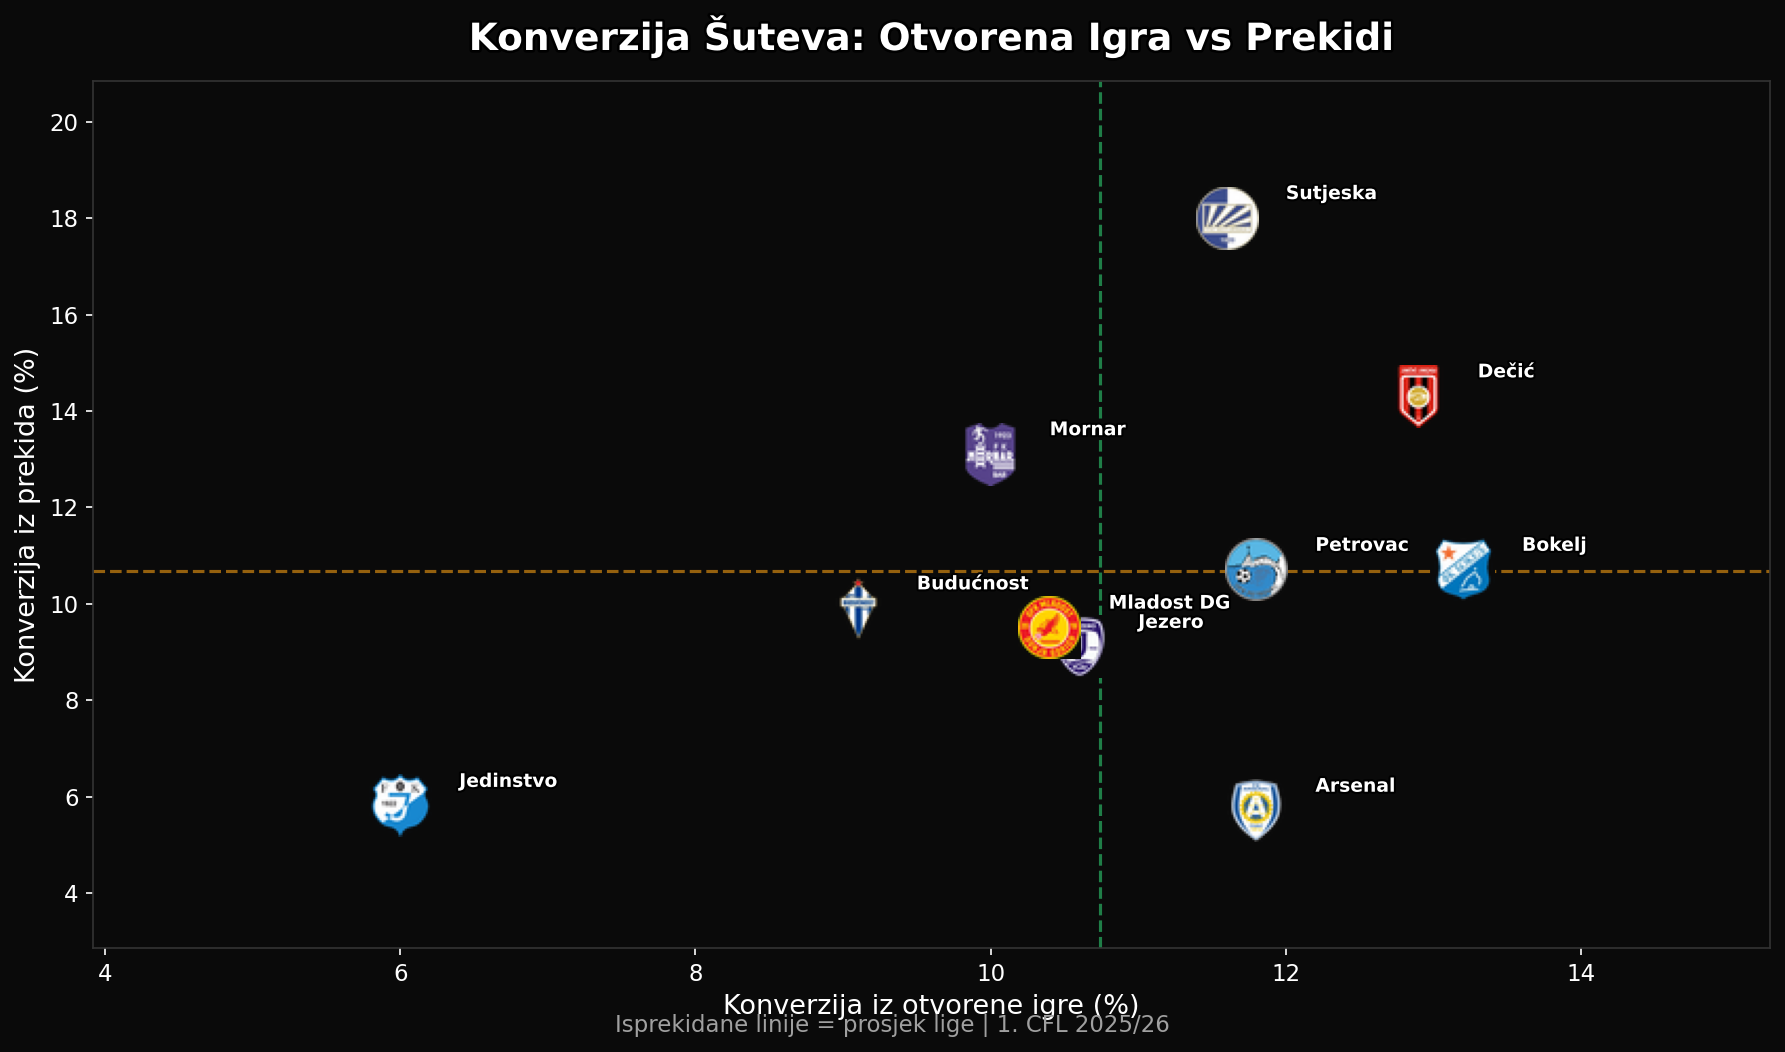

In [28]:
# ─── Figure 6: Open Play vs Set Piece Conversion Rate by Team ─
open_play = shot_eff[shot_eff['situation_group'] == 'Otvorena igra'].set_index('team_name')
set_piece = shot_eff[shot_eff['situation_group'] == 'Prekid'].set_index('team_name')

all_teams = sorted(shots['team_name'].dropna().unique())

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Collect data points first for axis limits
points = []
for team in all_teams:
    op_conv = open_play.loc[team, 'conversion'] if team in open_play.index else 0
    sp_conv = set_piece.loc[team, 'conversion'] if team in set_piece.index else 0
    points.append((team, op_conv, sp_conv))

# Set axis limits with padding before adding logos
all_x = [p[1] for p in points]
all_y = [p[2] for p in points]
x_pad = (max(all_x) - min(all_x)) * 0.15 + 1
y_pad = (max(all_y) - min(all_y)) * 0.15 + 1
ax.set_xlim(min(all_x) - x_pad, max(all_x) + x_pad)
ax.set_ylim(min(all_y) - y_pad, max(all_y) + y_pad)

def load_logo(path, size=30):
    """Load a PNG logo and composite onto dark background to fix alpha rendering."""
    img = Image.open(path).convert('RGBA')
    img.thumbnail((size, size), Image.Resampling.LANCZOS)
    bg = Image.new('RGBA', img.size, (10, 10, 10, 255))
    bg.paste(img, (0, 0), img)
    return np.array(bg.convert('RGB'))

for team, op_conv, sp_conv in points:
    s_name = team_id_map.get(team, team.replace('FK ', '').replace('OFK ', ''))
    
    # Try to load team logo
    tid = teams_meta[teams_meta['team_name'] == team]['team_id'].values
    logo_path = TEAM_LOGOS_DIR / f'{tid[0]}.png' if len(tid) > 0 else None
    
    if logo_path and logo_path.exists():
        logo_arr = load_logo(logo_path, size=30)
        imagebox = OffsetImage(logo_arr, zoom=1)
        ab = AnnotationBbox(imagebox, (op_conv, sp_conv), frameon=False, zorder=5)
        ax.add_artist(ab)
    else:
        ax.scatter(op_conv, sp_conv, s=120, color=GOLD, edgecolors='white',
                   linewidth=1, zorder=5)
    
    t = ax.text(op_conv + 0.4, sp_conv + 0.4, s_name, fontsize=9, color=TEXT_WHITE,
                fontweight='bold', zorder=6)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

# Average lines
avg_op = open_play['conversion'].mean()
avg_sp = set_piece['conversion'].mean()
ax.axvline(avg_op, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.6, zorder=2)
ax.axhline(avg_sp, color=ORANGE, linewidth=1.5, linestyle='--', alpha=0.6, zorder=2)

ax.set_xlabel('Konverzija iz otvorene igre (%)', fontsize=13, color=TEXT_WHITE)
ax.set_ylabel('Konverzija iz prekida (%)', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

title = ax.set_title('Konverzija Šuteva: Otvorena Igra vs Prekidi',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, 'Isprekidane linije = prosjek lige | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'conversion_open_vs_setpiece.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: conversion_open_vs_setpiece.png')
plt.show()

In [29]:
# ─── Load Team-Level Aggregated Stats ────────────────────────
team_stats = pd.read_csv(DATA_DIR / 'match_team_statistics.csv')
standings = pd.read_csv(DATA_DIR / 'league_standings.csv')

# Aggregate per-team averages across all matches
team_agg = team_stats.groupby('team_name').agg(
    matches_played=('match_id', 'nunique'),
    total_xg=('expectedGoals', 'sum'),
    avg_possession=('ballPossession', 'mean'),
    avg_fouls=('fouls', 'mean'),
    avg_yellow_cards=('yellowCards', 'mean'),
    total_shots_inside=('totalShotsInsideBox', 'sum'),
    total_shots_outside=('totalShotsOutsideBox', 'sum'),
    total_shots_on_goal=('totalShotsOnGoal', 'sum'),
).reset_index()

# Merge standings for points & goals
team_agg = team_agg.merge(
    standings[['team_name', 'points', 'played', 'goals_for', 'goals_against']],
    on='team_name', how='left'
)
team_agg['ppg'] = (team_agg['points'] / team_agg['played']).round(2)
team_agg['short'] = team_agg['team_name'].map(team_id_map).fillna(
    team_agg['team_name'].str.replace('FK ', '', regex=False).str.replace('OFK ', '', regex=False)
)

# xG conceded per game: get opponent xG from same match
team_xg_conceded = team_stats.merge(
    team_stats[['match_id', 'team_name', 'expectedGoals']],
    on='match_id', suffixes=('', '_opp')
)
team_xg_conceded = team_xg_conceded[team_xg_conceded['team_name'] != team_xg_conceded['team_name_opp']]
xg_conceded = team_xg_conceded.groupby('team_name')['expectedGoals_opp'].sum().reset_index()
xg_conceded.columns = ['team_name', 'total_xg_conceded']
team_agg = team_agg.merge(xg_conceded, on='team_name', how='left')

team_agg['xg_per_game'] = (team_agg['total_xg'] / team_agg['matches_played']).round(2)
team_agg['xg_conceded_per_game'] = (team_agg['total_xg_conceded'] / team_agg['matches_played']).round(2)

print(f'✅ Loaded team aggregate stats for {len(team_agg)} teams')
print(team_agg[['short', 'ppg', 'xg_per_game', 'xg_conceded_per_game', 'avg_possession']].to_string(index=False))

✅ Loaded team aggregate stats for 10 teams
     short  ppg  xg_per_game  xg_conceded_per_game  avg_possession
   Arsenal 1.05         0.74                  0.99       42.583333
    Bokelj 1.00         1.07                  1.34       45.125000
 Budućnost 1.32         1.19                  0.97       54.208333
     Dečić 1.63         0.95                  1.17       49.750000
 Jedinstvo 0.79         0.89                  1.03       46.916667
    Jezero 1.53         1.21                  1.28       51.166667
    Mornar 1.68         1.29                  1.06       52.625000
  Sutjeska 1.89         1.41                  0.94       52.500000
Mladost DG 1.37         1.27                  1.36       53.000000
  Petrovac 1.37         1.09                  0.99       52.125000


✅ Saved: xg_vs_goals_scatter.png


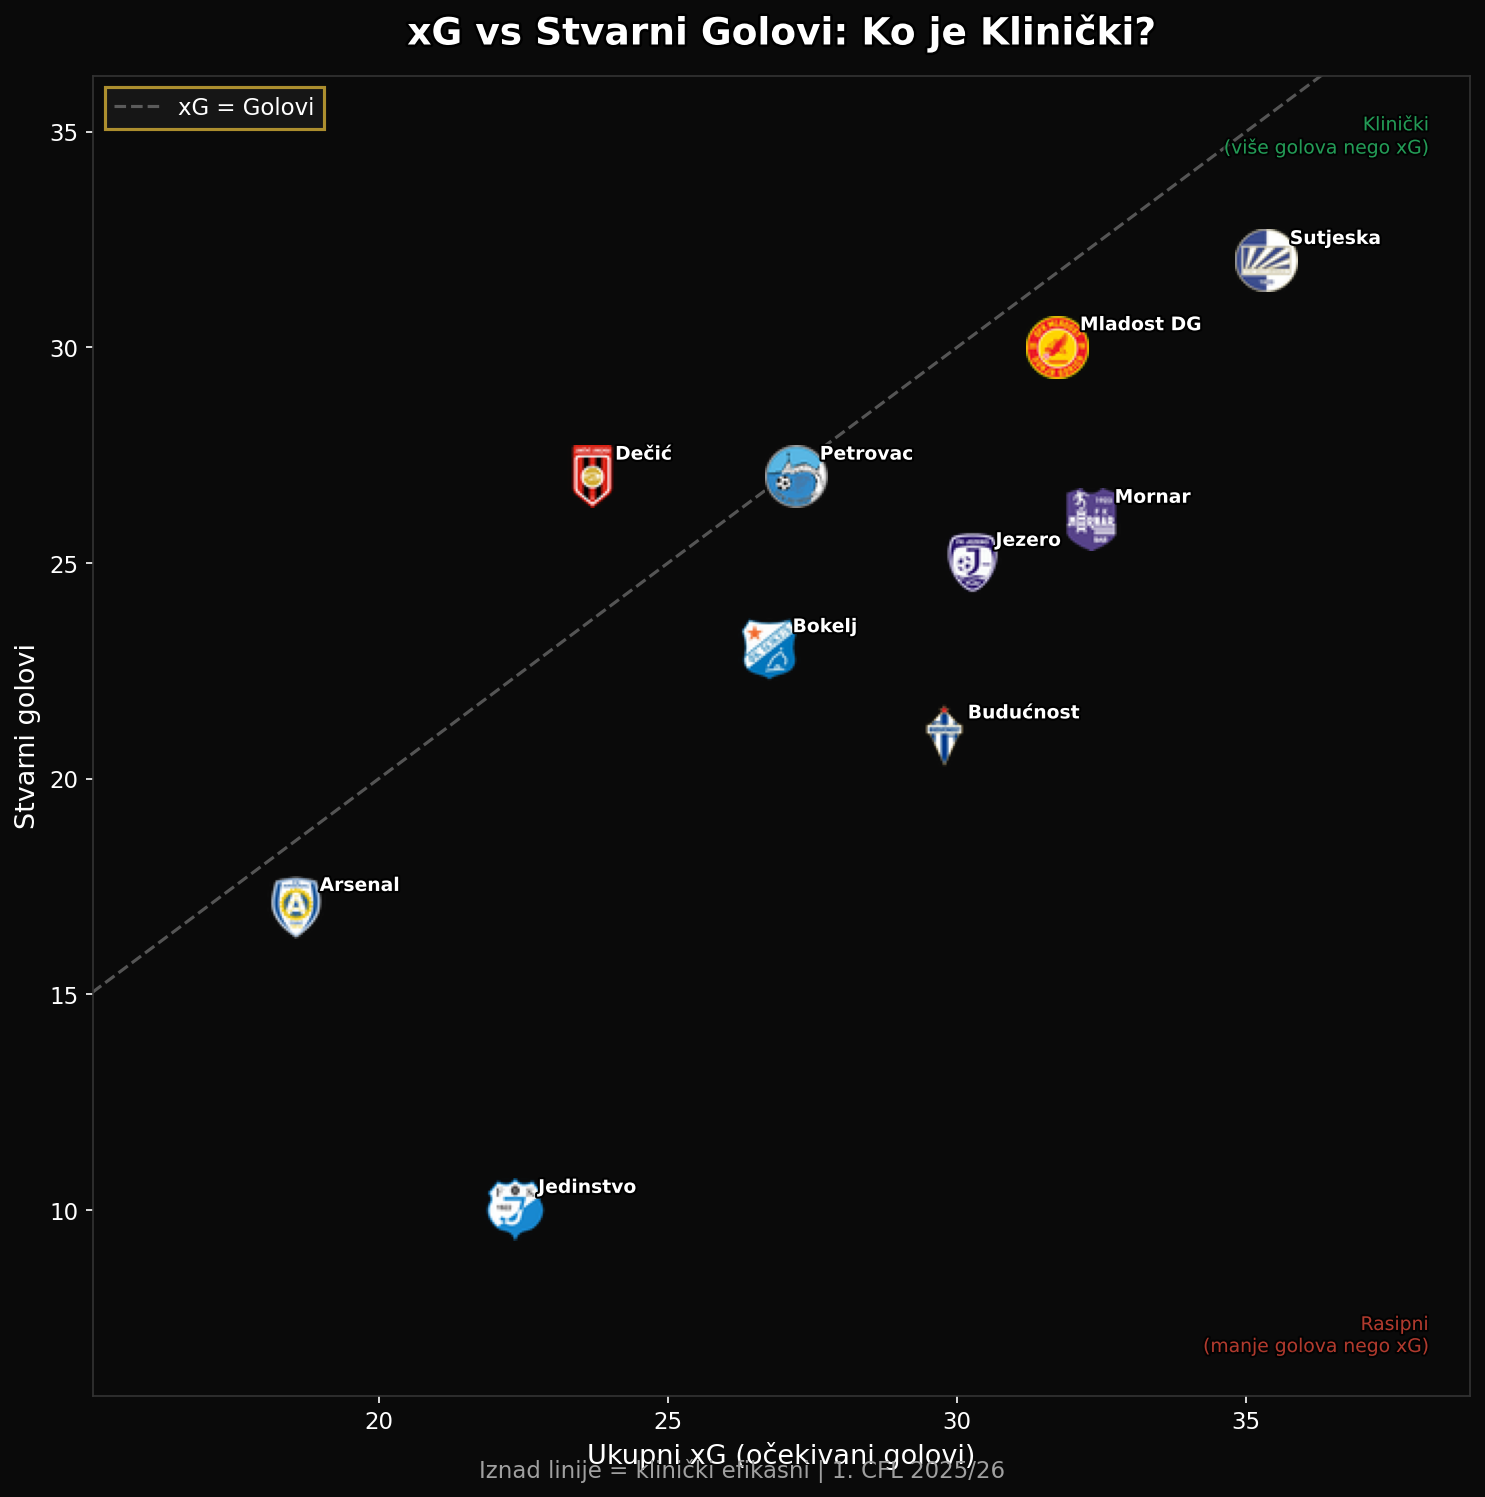

In [30]:
# ─── Figure 7: xG vs Actual Goals Scored ─────────────────────
# Who is clinical? Who wastes chances?

def load_logo(path, size=30):
    """Load a PNG logo and composite onto dark background to fix alpha rendering."""
    img = Image.open(path).convert('RGBA')
    img.thumbnail((size, size), Image.Resampling.LANCZOS)
    bg = Image.new('RGBA', img.size, (10, 10, 10, 255))
    bg.paste(img, (0, 0), img)
    return np.array(bg.convert('RGB'))

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

x_vals = team_agg['total_xg'].values
y_vals = team_agg['goals_for'].values

# Diagonal line (xG = Goals)
lo = min(min(x_vals), min(y_vals)) - 2
hi = max(max(x_vals), max(y_vals)) + 2
ax.plot([lo, hi], [lo, hi], color=TEXT_GREY, linewidth=1.5, linestyle='--', alpha=0.5, zorder=2,
        label='xG = Golovi')

x_pad = (max(x_vals) - min(x_vals)) * 0.15 + 1
y_pad = (max(y_vals) - min(y_vals)) * 0.15 + 1
ax.set_xlim(min(x_vals) - x_pad, max(x_vals) + x_pad)
ax.set_ylim(min(y_vals) - y_pad, max(y_vals) + y_pad)

for _, row in team_agg.iterrows():
    tid = teams_meta[teams_meta['team_name'] == row['team_name']]['team_id'].values
    logo_path = TEAM_LOGOS_DIR / f'{tid[0]}.png' if len(tid) > 0 else None

    if logo_path and logo_path.exists():
        logo_arr = load_logo(logo_path, size=30)
        imagebox = OffsetImage(logo_arr, zoom=1)
        ab = AnnotationBbox(imagebox, (row['total_xg'], row['goals_for']), frameon=False, zorder=5)
        ax.add_artist(ab)
    else:
        ax.scatter(row['total_xg'], row['goals_for'], s=120, color=GOLD, edgecolors='white',
                   linewidth=1, zorder=5)

    t = ax.text(row['total_xg'] + 0.4, row['goals_for'] + 0.4, row['short'],
                fontsize=9, color=TEXT_WHITE, fontweight='bold', zorder=6)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

# Quadrant labels
ax.text(0.97, 0.97, 'Klinički\n(više golova nego xG)', transform=ax.transAxes,
        fontsize=9, color=GREEN, ha='right', va='top', alpha=0.7,
        path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
ax.text(0.97, 0.03, 'Rasipni\n(manje golova nego xG)', transform=ax.transAxes,
        fontsize=9, color=RED, ha='right', va='bottom', alpha=0.7,
        path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_xlabel('Ukupni xG (očekivani golovi)', fontsize=13, color=TEXT_WHITE)
ax.set_ylabel('Stvarni golovi', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

legend = ax.legend(fontsize=11, fancybox=False, edgecolor=GOLD, facecolor='#1a1a1a',
                   labelcolor=TEXT_WHITE, loc='upper left')
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('xG vs Stvarni Golovi: Ko je Klinički?',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, 'Iznad linije = klinički efikasni | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xg_vs_goals_scatter.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: xg_vs_goals_scatter.png')
plt.show()

✅ Saved: possession_vs_points_scatter.png


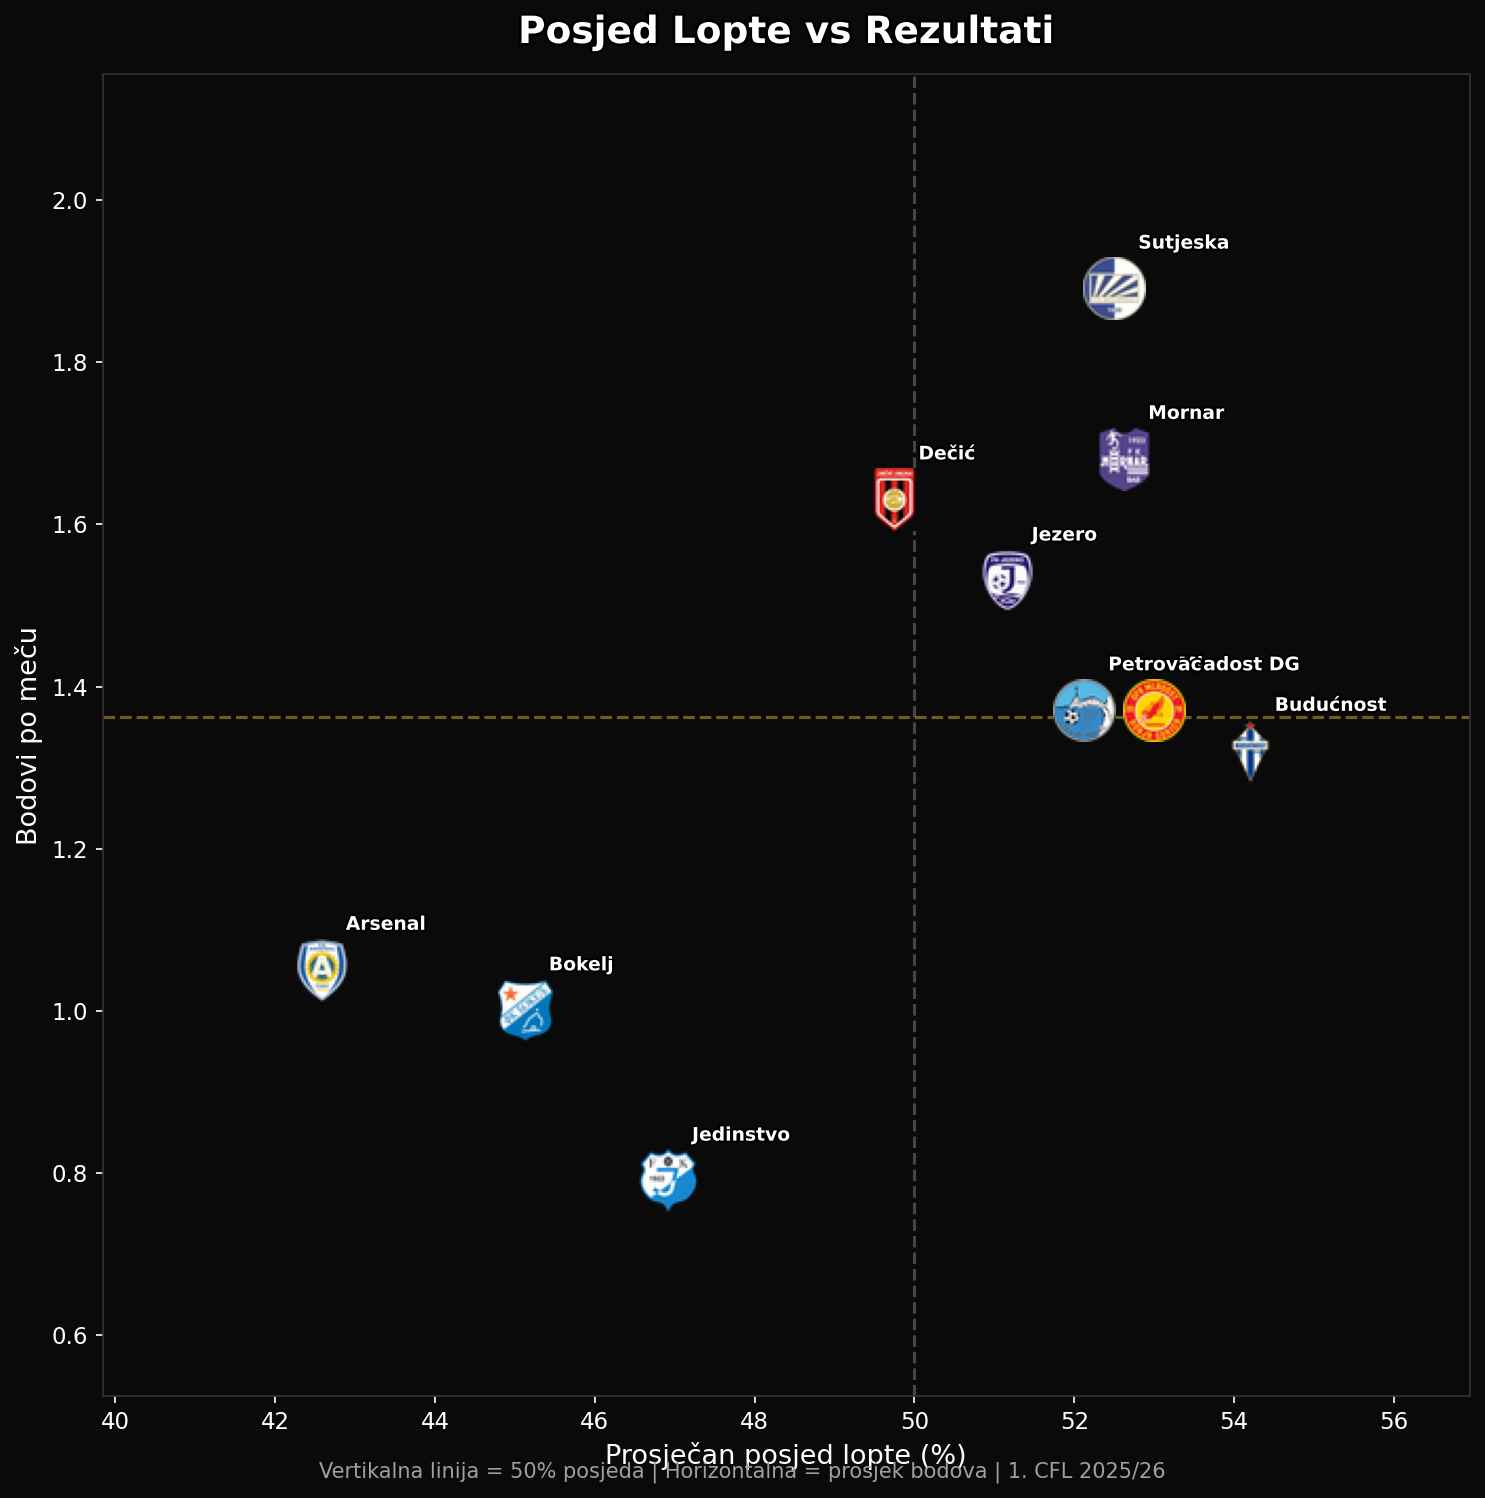

In [31]:
# ─── Figure 8: Possession vs Points per Game ─────────────────
# Does controlling the ball translate to results?

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

x_vals = team_agg['avg_possession'].values
y_vals = team_agg['ppg'].values

x_pad = (max(x_vals) - min(x_vals)) * 0.15 + 1
y_pad = (max(y_vals) - min(y_vals)) * 0.15 + 0.1
ax.set_xlim(min(x_vals) - x_pad, max(x_vals) + x_pad)
ax.set_ylim(min(y_vals) - y_pad, max(y_vals) + y_pad)

# League average lines
ax.axvline(50, color=TEXT_GREY, linewidth=1.5, linestyle='--', alpha=0.4, zorder=2)
avg_ppg = team_agg['ppg'].mean()
ax.axhline(avg_ppg, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.5, zorder=2)

for _, row in team_agg.iterrows():
    tid = teams_meta[teams_meta['team_name'] == row['team_name']]['team_id'].values
    logo_path = TEAM_LOGOS_DIR / f'{tid[0]}.png' if len(tid) > 0 else None

    if logo_path and logo_path.exists():
        logo_arr = load_logo(logo_path, size=30)
        imagebox = OffsetImage(logo_arr, zoom=1)
        ab = AnnotationBbox(imagebox, (row['avg_possession'], row['ppg']), frameon=False, zorder=5)
        ax.add_artist(ab)
    else:
        ax.scatter(row['avg_possession'], row['ppg'], s=120, color=GOLD,
                   edgecolors='white', linewidth=1, zorder=5)

    t = ax.text(row['avg_possession'] + 0.3, row['ppg'] + 0.05, row['short'],
                fontsize=9, color=TEXT_WHITE, fontweight='bold', zorder=6)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_xlabel('Prosječan posjed lopte (%)', fontsize=13, color=TEXT_WHITE)
ax.set_ylabel('Bodovi po meču', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

title = ax.set_title('Posjed Lopte vs Rezultati',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, 'Vertikalna linija = 50% posjeda | Horizontalna = prosjek bodova | 1. CFL 2025/26',
         fontsize=10, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'possession_vs_points_scatter.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: possession_vs_points_scatter.png')
plt.show()

✅ Saved: xg_attack_vs_defense_scatter.png


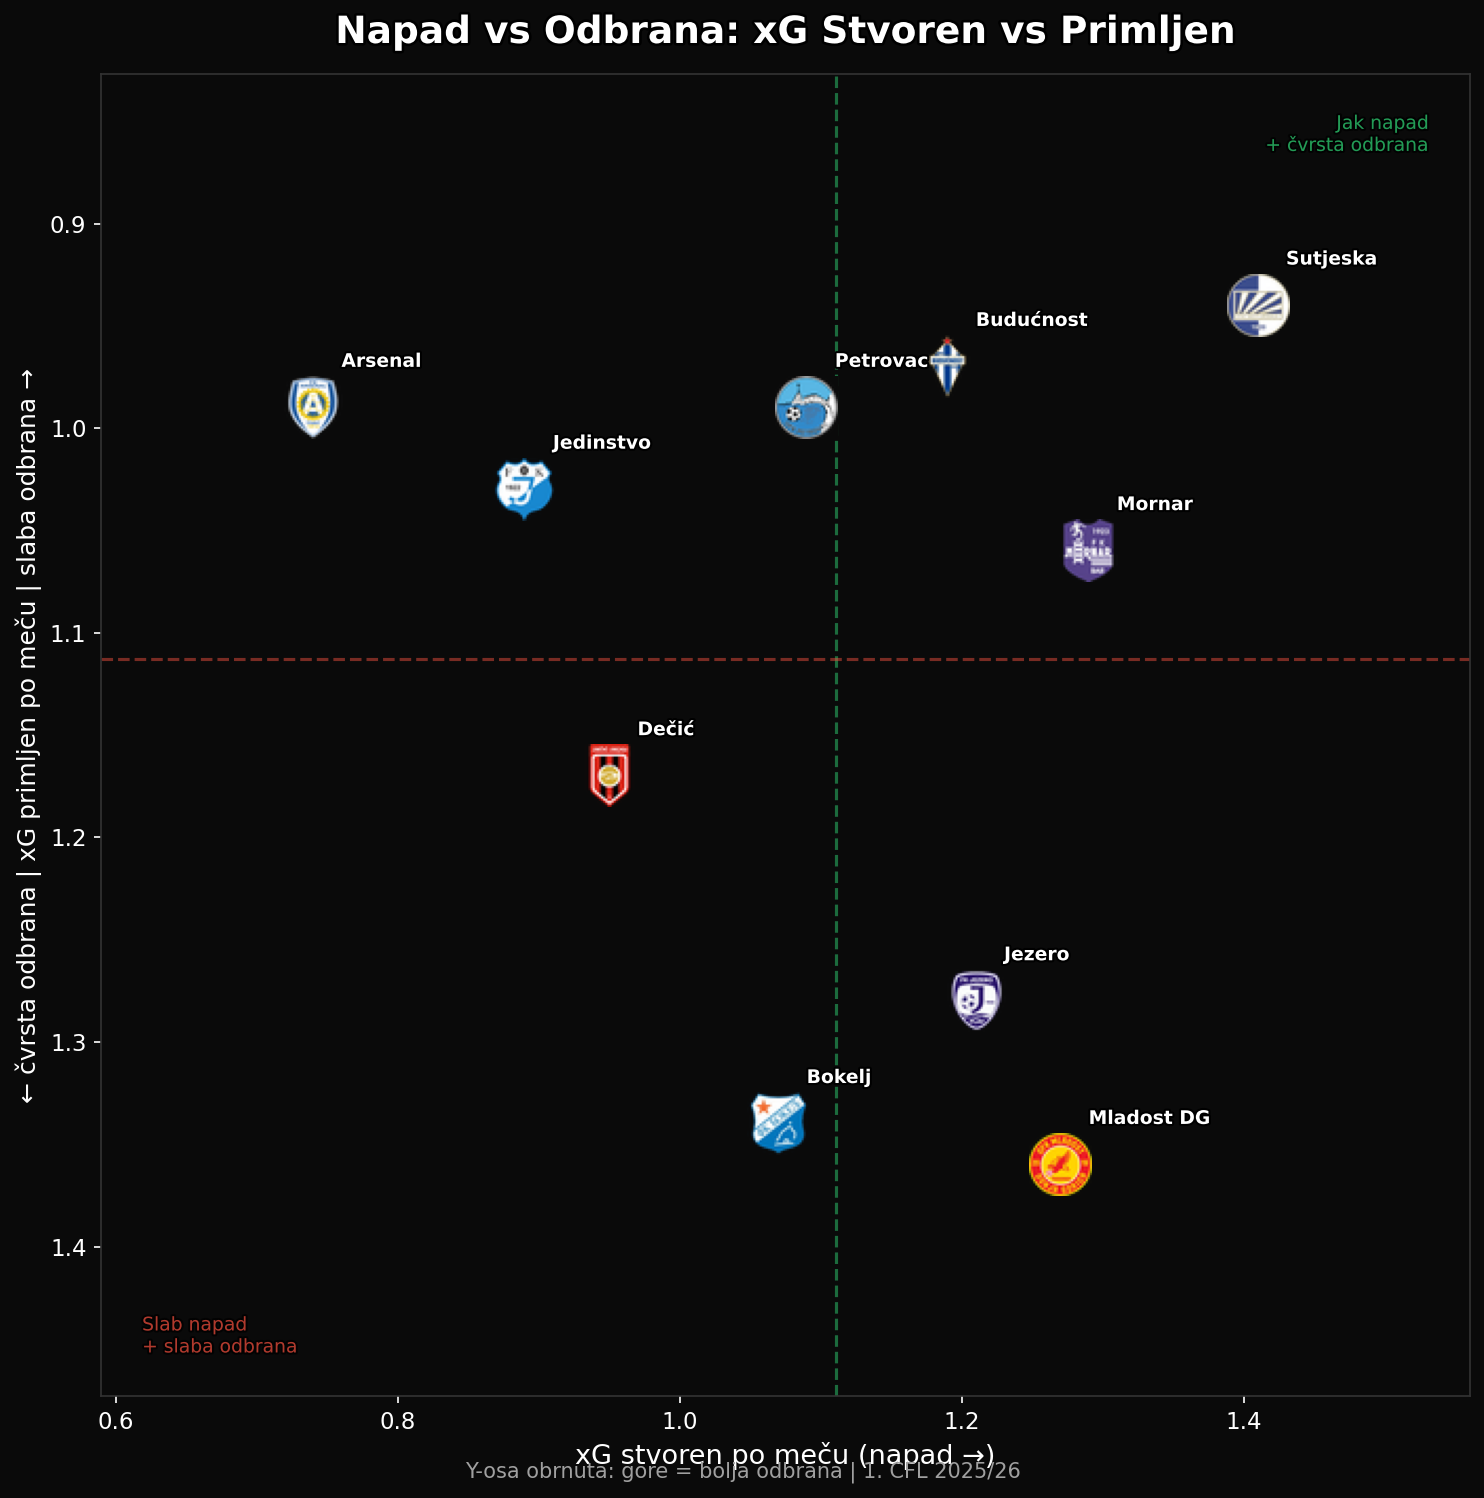

In [32]:
# ─── Figure 9: xG Created vs xG Conceded per Game ────────────
# Quadrant chart: attack quality vs defensive solidity

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

x_vals = team_agg['xg_per_game'].values
y_vals = team_agg['xg_conceded_per_game'].values

x_pad = (max(x_vals) - min(x_vals)) * 0.15 + 0.05
y_pad = (max(y_vals) - min(y_vals)) * 0.15 + 0.05
ax.set_xlim(min(x_vals) - x_pad, max(x_vals) + x_pad)
ax.set_ylim(max(y_vals) + y_pad, min(y_vals) - y_pad)  # INVERTED: low conceded at top

# League average lines
avg_xg_created = team_agg['xg_per_game'].mean()
avg_xg_conceded = team_agg['xg_conceded_per_game'].mean()
ax.axvline(avg_xg_created, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.5, zorder=2)
ax.axhline(avg_xg_conceded, color=RED, linewidth=1.5, linestyle='--', alpha=0.5, zorder=2)

for _, row in team_agg.iterrows():
    tid = teams_meta[teams_meta['team_name'] == row['team_name']]['team_id'].values
    logo_path = TEAM_LOGOS_DIR / f'{tid[0]}.png' if len(tid) > 0 else None

    if logo_path and logo_path.exists():
        logo_arr = load_logo(logo_path, size=30)
        imagebox = OffsetImage(logo_arr, zoom=1)
        ab = AnnotationBbox(imagebox, (row['xg_per_game'], row['xg_conceded_per_game']),
                           frameon=False, zorder=5)
        ax.add_artist(ab)
    else:
        ax.scatter(row['xg_per_game'], row['xg_conceded_per_game'], s=120, color=GOLD,
                   edgecolors='white', linewidth=1, zorder=5)

    t = ax.text(row['xg_per_game'] + 0.02, row['xg_conceded_per_game'] - 0.02, row['short'],
                fontsize=9, color=TEXT_WHITE, fontweight='bold', zorder=6)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

# Quadrant labels
ax.text(0.97, 0.97, 'Jak napad\n+ čvrsta odbrana', transform=ax.transAxes,
        fontsize=9, color=GREEN, ha='right', va='top', alpha=0.7,
        path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
ax.text(0.03, 0.03, 'Slab napad\n+ slaba odbrana', transform=ax.transAxes,
        fontsize=9, color=RED, ha='left', va='bottom', alpha=0.7,
        path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_xlabel('xG stvoren po meču (napad →)', fontsize=13, color=TEXT_WHITE)
ax.set_ylabel('← čvrsta odbrana | xG primljen po meču | slaba odbrana →', fontsize=12, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

title = ax.set_title('Napad vs Odbrana: xG Stvoren vs Primljen',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()])
fig.text(0.5, 0.01, 'Y-osa obrnuta: gore = bolja odbrana | 1. CFL 2025/26',
         fontsize=10, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xg_attack_vs_defense_scatter.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: xg_attack_vs_defense_scatter.png')
plt.show()